# Parkinson’s Disease

Parkinson’s Disease (PD) is a degenerative neurological disorder marked by decreased dopamine levels in the brain. It manifests itself through a deterioration of movement, including the presence of tremors and stiffness. There is commonly a marked effect on speech, including dysarthria (difficulty articulating sounds), hypophonia (lowered volume), and monotone (reduced pitch range). Additionally, cognitive impairments and changes in mood can occur, and risk of dementia is increased.

Traditional diagnosis of Parkinson’s Disease involves a clinician taking a neurological history of the patient and observing motor skills in various situations. Since there is no definitive laboratory test to diagnose PD, diagnosis is often difficult, particularly in the early stages when motor effects are not yet severe. Monitoring progression of the disease over time requires repeated clinic visits by the patient. An effective screening process, particularly one that doesn’t require a clinic visit, would be beneficial. Since PD patients exhibit characteristic vocal features, voice recordings are a useful and non-invasive tool for diagnosis. If machine learning algorithms could be applied to a voice recording dataset to accurately diagnosis PD, this would be an effective screening step prior to an appointment with a clinician.

The data & attributes information for this project is available at https://archive.ics.uci.edu/ml/machine-learning-databases/parkinsons/ (Links to an external site.)Links to an external site. The data consists of those diagnosed with Parkinson Disease and those who do not.

**Steps to be followed:**

1. Use a Python notebook & Load the dataset
2. It is always a good practice to eye-ball raw data to get a feel of the data in terms of number of structure of the file, number of attributes, types of attributes and a general idea of likely challenges in the dataset. (2.5 points)
3. Using univariate & bivariate analysis to check the individual attributes for their basic statistic such as central values, spread, tails etc. What are your observations? (15 points)
4. Split the dataset into training and test set in the ratio of 70:30 (Training:Test).
5. Create the model using “entropy” method of reducing the entropy and fit it to training data. (5 points)
6. Test the model on test data and what is the accuracy achieved. Capture the predicted values and do a crosstab. (7.5 points)
7. Use regularization parameters of max_depth, min_sample_leaf to recreate the model. What is the impact on the model accuracy? How does regularization help? (20 points) 
8. Next implement the decision tree using Random Forest. What is the optimal number of trees that gives the best result? (10 points)


# Imports and Load Dataset
### Q1. Use a Python notebook & Load the dataset

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import sklearn.metrics as metrics
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold, cross_val_score

import warnings 
warnings.filterwarnings('ignore')

%matplotlib inline

In [3]:
df = pd.read_csv("parkinsons.data")
df.sample(10,axis=0)

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
184,phon_R01_S49_2,116.848,217.552,99.503,0.00531,0.00005,0.00260,0.00346,0.00780,0.01795,...,0.02429,0.01179,22.085,0,0.663842,0.656516,-5.198864,0.206768,2.120412,0.252404
71,phon_R01_S18_6,136.358,176.595,65.750,0.00971,0.00007,0.00534,0.00478,0.01601,0.04978,...,0.08247,0.03361,18.570,1,0.543299,0.733232,-5.207985,0.224852,2.642276,0.242981
136,phon_R01_S33_3,113.400,133.344,107.816,0.00451,0.00004,0.00219,0.00283,0.00658,0.04879,...,0.07154,0.02278,19.013,1,0.647900,0.708144,-4.378916,0.300067,2.445502,0.259451
169,phon_R01_S42_5,240.301,245.135,219.783,0.00517,0.00002,0.00316,0.00283,0.00949,0.02018,...,0.03529,0.00965,21.020,0,0.371837,0.646167,-7.169701,0.073298,2.266432,0.100881
65,phon_R01_S17_6,228.969,239.541,113.201,0.00238,0.00001,0.00136,0.00140,0.00408,0.01745,...,0.02827,0.00420,24.547,0,0.305429,0.681811,-7.314237,0.006274,2.118596,0.091546
75,phon_R01_S19_4,110.707,122.611,105.007,0.00516,0.00005,0.00277,0.00289,0.00831,0.02215,...,0.03851,0.00472,25.197,1,0.463514,0.807217,-5.477592,0.315074,1.862092,0.228624
80,phon_R01_S20_3,96.106,108.664,84.510,0.00694,0.00007,0.00389,0.00415,0.01168,0.04024,...,0.06799,0.01823,19.055,1,0.544805,0.770466,-4.441519,0.155097,2.645959,0.327978
163,phon_R01_S39_5,112.150,131.669,97.527,0.00519,0.00005,0.00291,0.00284,0.00873,0.01756,...,0.02902,0.01435,21.219,1,0.557045,0.673086,-5.617124,0.184896,1.871871,0.212386
19,phon_R01_S05_2,156.405,189.398,142.822,0.00768,0.00005,0.00372,0.00399,0.01116,0.03995,...,0.05164,0.03365,17.153,1,0.649554,0.686080,-4.554466,0.340176,2.856676,0.322111
156,phon_R01_S37_4,122.336,142.369,94.794,0.00727,0.00006,0.00415,0.00339,0.01246,0.02293,...,0.03615,0.03191,22.953,1,0.611679,0.623731,-5.435100,0.230532,2.699645,0.220546


## Sanitize Data
### Q2. It is always a good practice to eye-ball raw data to get a feel of the data in terms of number of structure of the file, number of attributes, types of attributes and a general idea of likely challenges in the dataset. (2.5 points)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
name                195 non-null object
MDVP:Fo(Hz)         195 non-null float64
MDVP:Fhi(Hz)        195 non-null float64
MDVP:Flo(Hz)        195 non-null float64
MDVP:Jitter(%)      195 non-null float64
MDVP:Jitter(Abs)    195 non-null float64
MDVP:RAP            195 non-null float64
MDVP:PPQ            195 non-null float64
Jitter:DDP          195 non-null float64
MDVP:Shimmer        195 non-null float64
MDVP:Shimmer(dB)    195 non-null float64
Shimmer:APQ3        195 non-null float64
Shimmer:APQ5        195 non-null float64
MDVP:APQ            195 non-null float64
Shimmer:DDA         195 non-null float64
NHR                 195 non-null float64
HNR                 195 non-null float64
status              195 non-null int64
RPDE                195 non-null float64
DFA                 195 non-null float64
spread1             195 non-null float64
spread2             195 non-null floa

In [5]:
df = df.drop("name",axis=1)

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MDVP:Fo(Hz),195.0,154.228641,41.390065,88.333000,117.572000,148.790000,182.769000,260.105000
MDVP:Fhi(Hz),195.0,197.104918,91.491548,102.145000,134.862500,175.829000,224.205500,592.030000
MDVP:Flo(Hz),195.0,116.324631,43.521413,65.476000,84.291000,104.315000,140.018500,239.170000
MDVP:Jitter(%),195.0,0.006220,0.004848,0.001680,0.003460,0.004940,0.007365,0.033160
MDVP:Jitter(Abs),195.0,0.000044,0.000035,0.000007,0.000020,0.000030,0.000060,0.000260
MDVP:RAP,195.0,0.003306,0.002968,0.000680,0.001660,0.002500,0.003835,0.021440
MDVP:PPQ,195.0,0.003446,0.002759,0.000920,0.001860,0.002690,0.003955,0.019580
Jitter:DDP,195.0,0.009920,0.008903,0.002040,0.004985,0.007490,0.011505,0.064330
MDVP:Shimmer,195.0,0.029709,0.018857,0.009540,0.016505,0.022970,0.037885,0.119080
MDVP:Shimmer(dB),195.0,0.282251,0.194877,0.085000,0.148500,0.221000,0.350000,1.302000


In [7]:
df.shape

(195, 23)

In [8]:
print("Number of NULL values in each column:")
print(df.isnull().apply(sum))
print(df.isna().apply(sum))

Number of NULL values in each column:
MDVP:Fo(Hz)         0
MDVP:Fhi(Hz)        0
MDVP:Flo(Hz)        0
MDVP:Jitter(%)      0
MDVP:Jitter(Abs)    0
MDVP:RAP            0
MDVP:PPQ            0
Jitter:DDP          0
MDVP:Shimmer        0
MDVP:Shimmer(dB)    0
Shimmer:APQ3        0
Shimmer:APQ5        0
MDVP:APQ            0
Shimmer:DDA         0
NHR                 0
HNR                 0
status              0
RPDE                0
DFA                 0
spread1             0
spread2             0
D2                  0
PPE                 0
dtype: int64
MDVP:Fo(Hz)         0
MDVP:Fhi(Hz)        0
MDVP:Flo(Hz)        0
MDVP:Jitter(%)      0
MDVP:Jitter(Abs)    0
MDVP:RAP            0
MDVP:PPQ            0
Jitter:DDP          0
MDVP:Shimmer        0
MDVP:Shimmer(dB)    0
Shimmer:APQ3        0
Shimmer:APQ5        0
MDVP:APQ            0
Shimmer:DDA         0
NHR                 0
HNR                 0
status              0
RPDE                0
DFA                 0
spread1             0
spr

### Observations:
- Total of 195 samples
- All the features are numerical and continious in nature except 'status' 
- 'status' is the dependent feature and is binary categorical value. 1-Parkinson's, 0-healthy
- Data set is clean, no zero or nan values.

# Exploratory Data Analysis
### Q3. Using univariate & bivariate analysis to check the individual attributes for their basic statistic such as central values, spread, tails etc. What are your observations? (15 points)

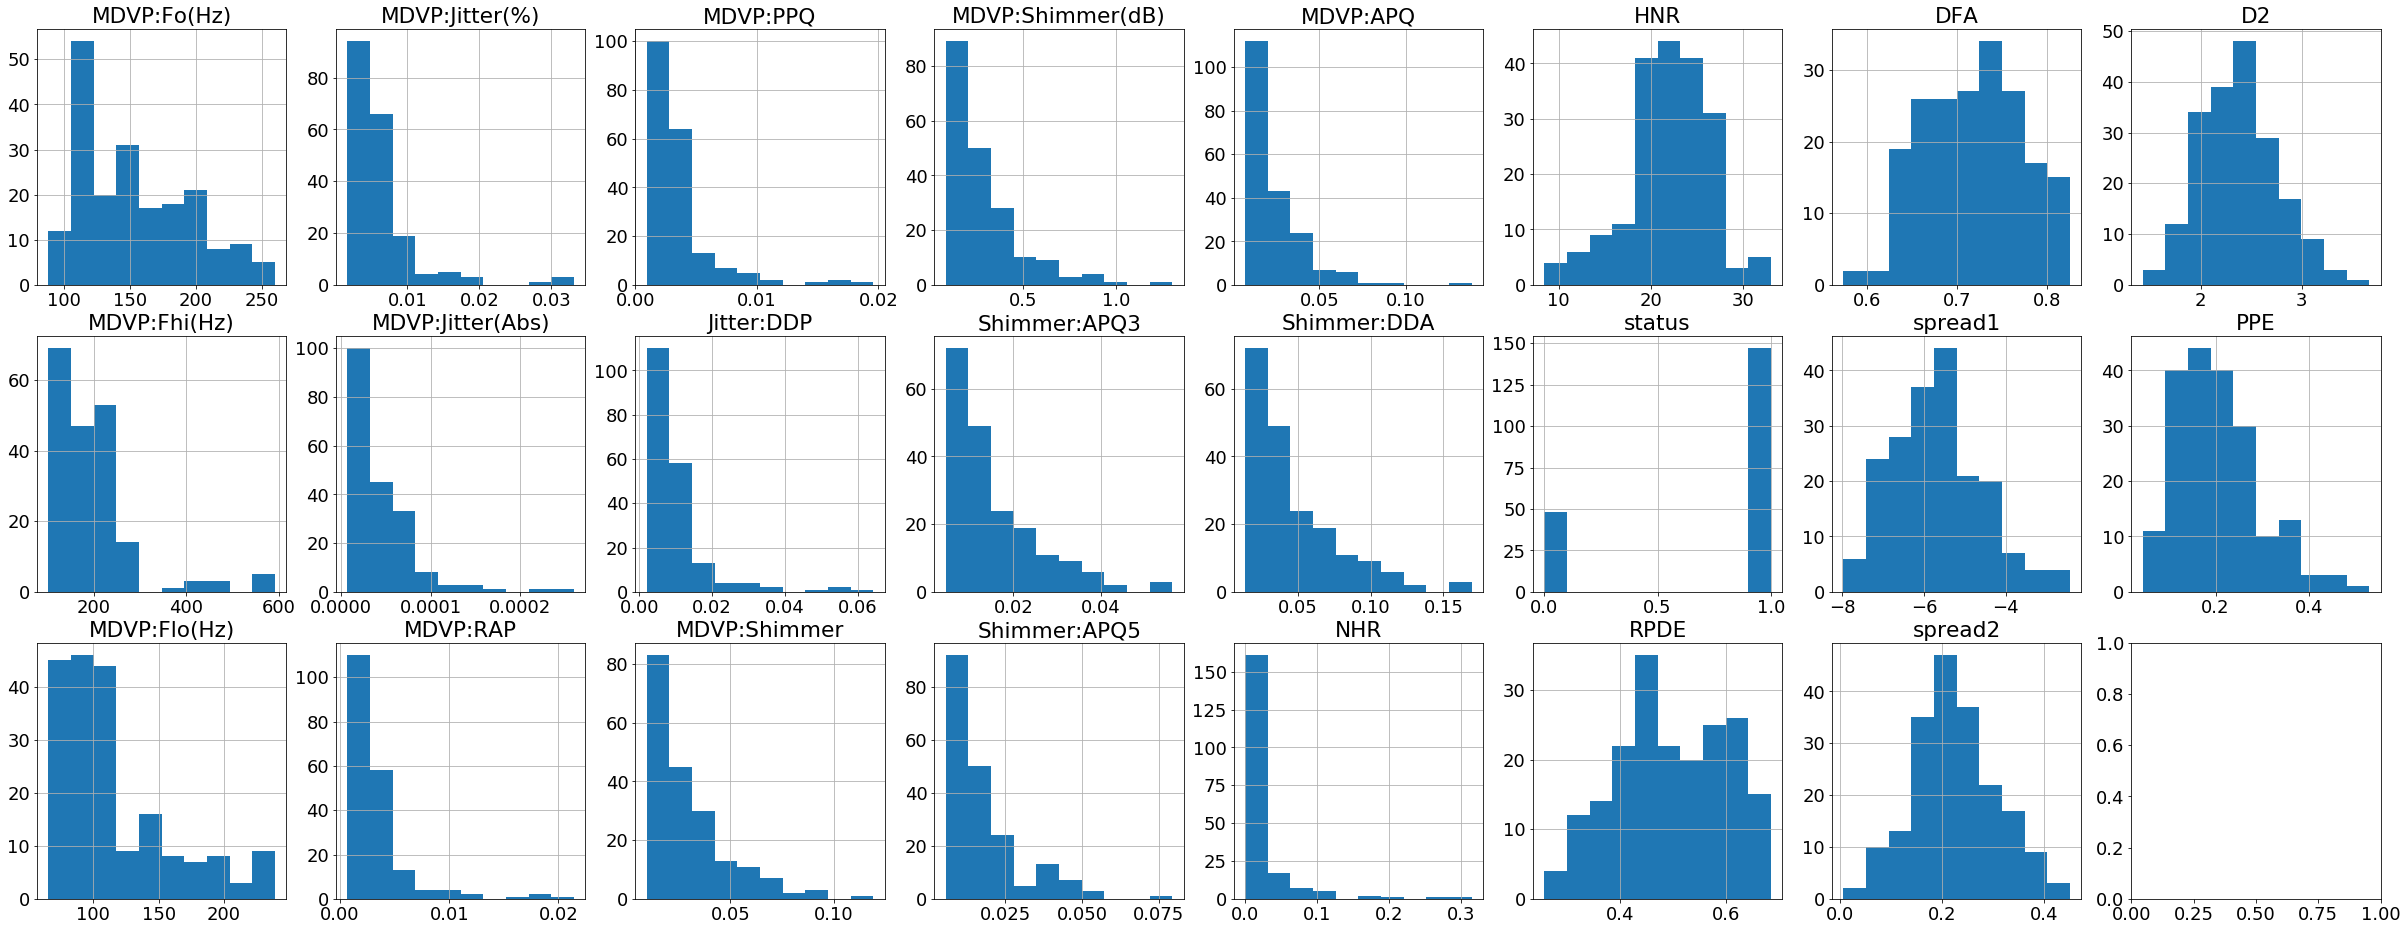

In [8]:
plt.rcParams.update({'font.size': 18})
fig, axes = plt.subplots(nrows=3, ncols=8, figsize=(42, 16))
for i in range (0,len(df.dtypes.keys())):
    df[df.dtypes.keys()[i]].hist(ax=axes[int(i%3), int(i/3)])
    axes[int(i%3), int(i/3)].set_title(df.dtypes.keys()[i])
plt.show()


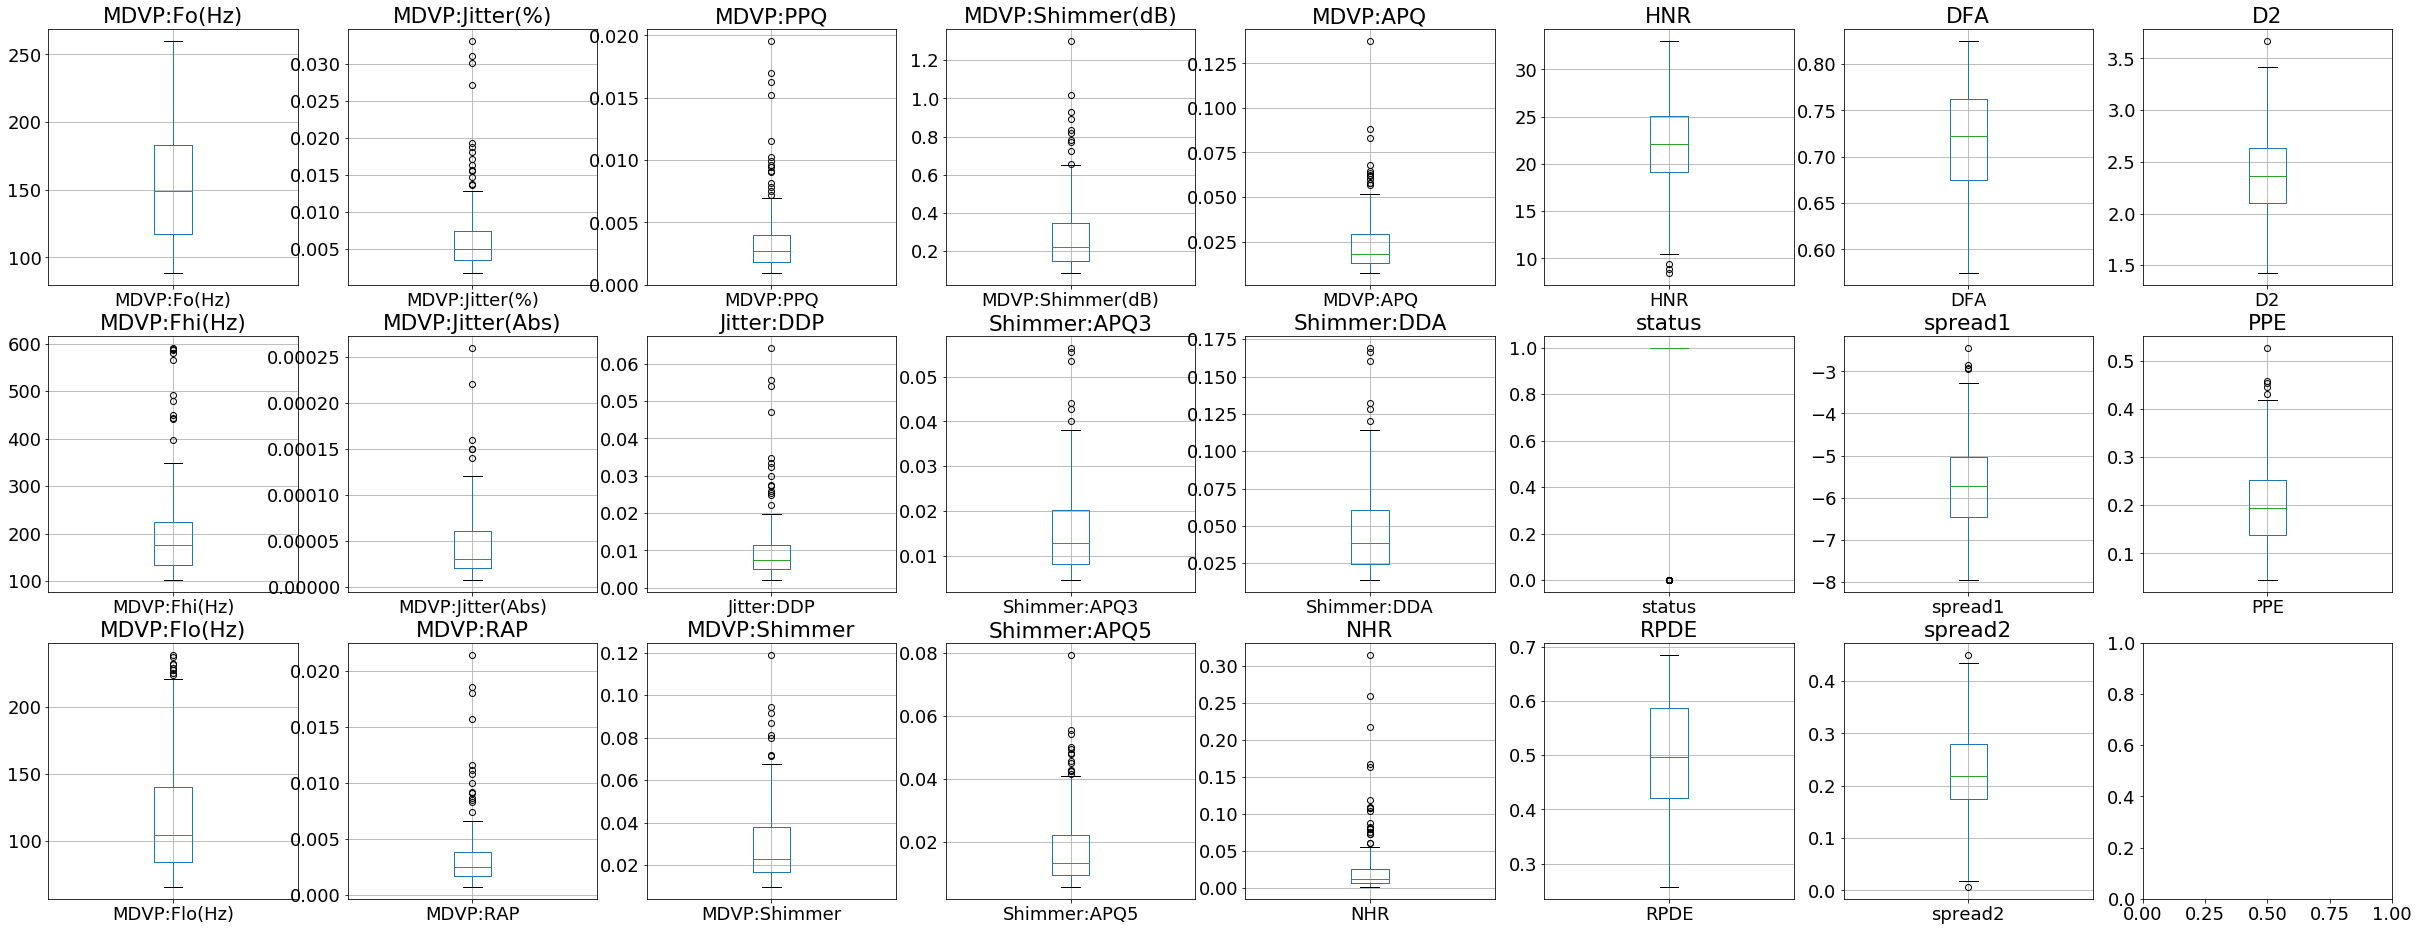

In [9]:
plt.rcParams.update({'font.size': 18})
fig, axes = plt.subplots(nrows=3, ncols=8, figsize=(42, 16))
for i in range (0,len(df.dtypes.keys())):
    df.boxplot(column=df.dtypes.keys()[i],ax=axes[int(i%3), int(i/3)])
    axes[int(i%3), int(i/3)].set_title(df.dtypes.keys()[i])
plt.show()

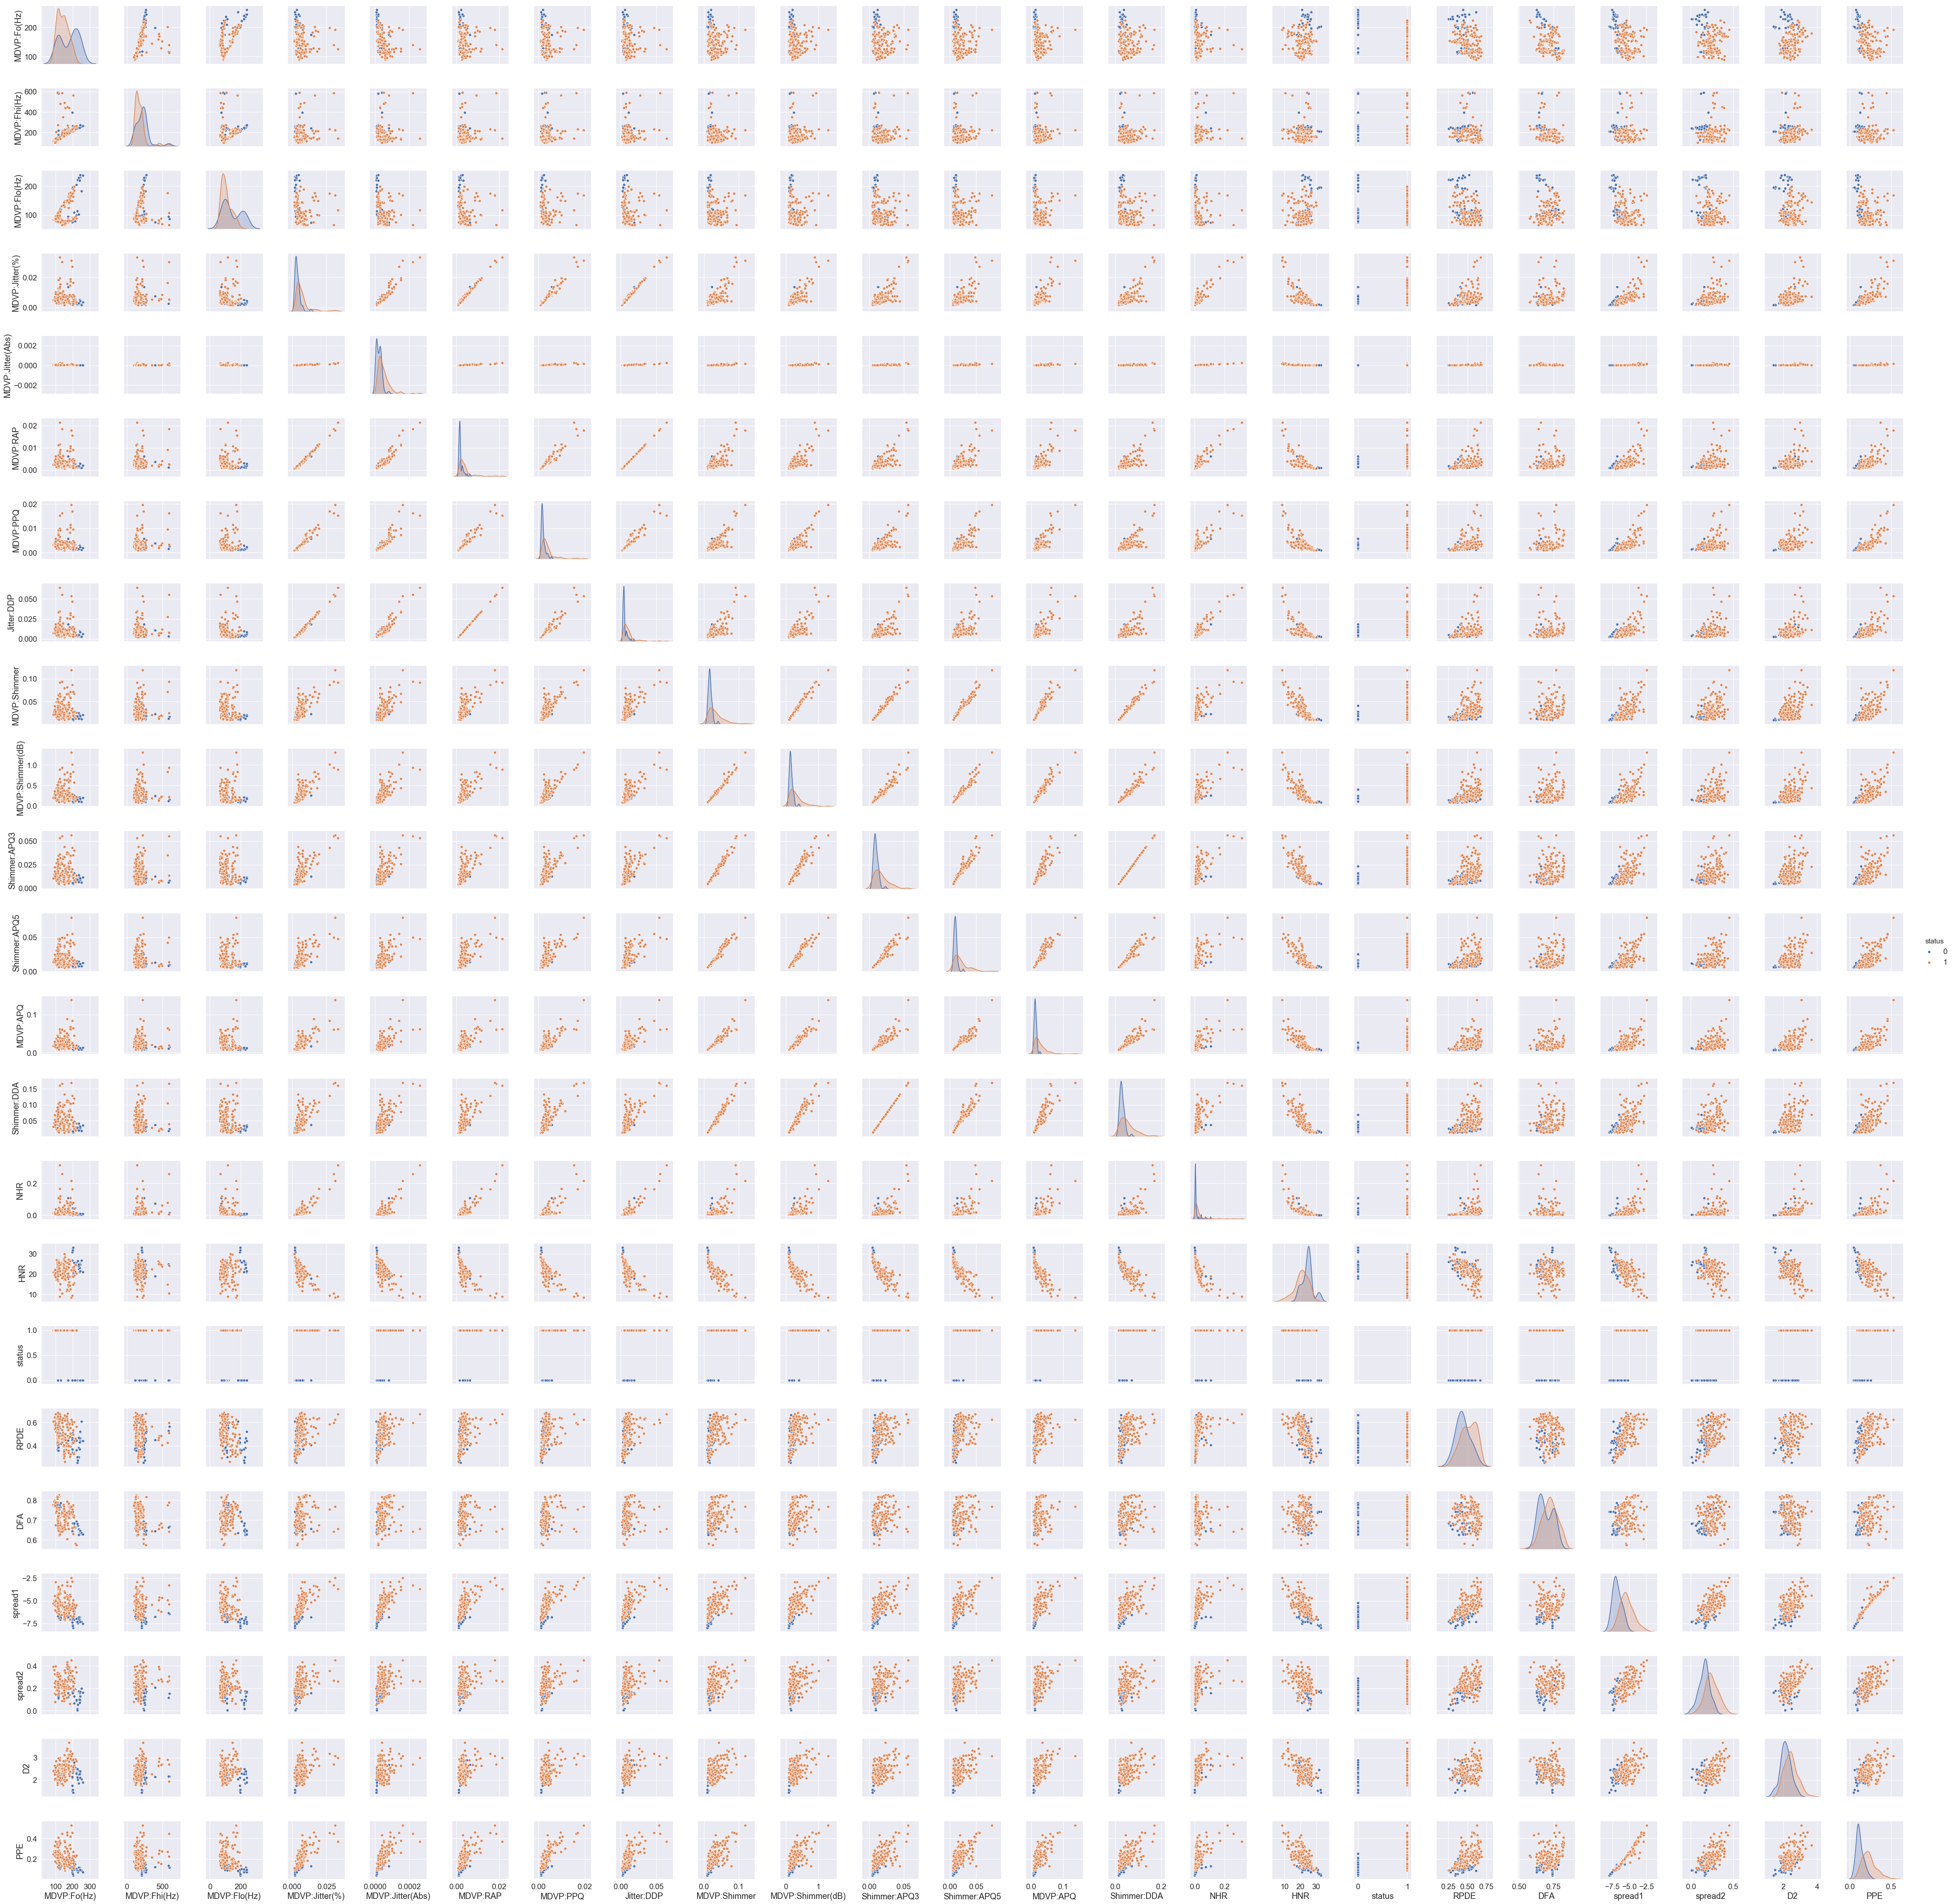

In [11]:
sns.set(font_scale=1.5)
_= sns.pairplot(df, hue="status")

### Observation:
- MDVP:Fo(Hz) - Seems to be normally distributed
- MDVP:Fhi(Hz) - Seems to be normally distributed with few outliers
- MDVP:Flo(Hz) - Seems to have long tail with few outliers
- MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP - Seems to be right skwed. More samples are closer to zero.
- MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA - Seems to be right skwed. More samples are closer to zero.
- NHR: Seems to right skewed with long tail
- HNR - Seems normally distributed
- status - Our dependent variables. There are more positive samples (about 150) with Parkinson’s Disease then negative (about 50) samples.
- RPDE,D2 - Seems to be normally distributed
- DFA - Seems to be normally distributed
- spread1,spread2,PPE - Seems to be normally distributed with few outliers

# Create Model
### Q4. Split the dataset into training and test set in the ratio of 70:30 (Training:Test).

In [9]:
X = df.drop("status",axis=1)
y = df["status"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=5)
print("Dataset Size: X_train: {}, X_test: {}, y_train {}, y_test: {}".format(X_train.shape, X_test.shape, y_train.shape, y_test.shape))

Dataset Size: X_train: (136, 22), X_test: (59, 22), y_train (136,), y_test: (59,)


### Q5. Create the model using “entropy” method of reducing the entropy and fit it to training data. (5 points)

In [10]:
dtModel=DecisionTreeClassifier(criterion='entropy',random_state=5)
dtModel.fit(X_train,y_train)

DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=None,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=5,
            splitter='best')

### Q6. Test the model on test data and what is the accuracy achieved. Capture the predicted values and do a crosstab. (7.5 points)

In [11]:
y_pred=dtModel.predict(X_test)
acc=metrics.accuracy_score(y_test,y_pred)
print(acc)

0.9322033898305084


In [12]:
cm=metrics.confusion_matrix(y_true=y_test,y_pred=y_pred)
print("Confusion Matrix:\n",cm)
print("\nClassification Report:\n",metrics.classification_report(y_test,y_pred))

Confusion Matrix:
 [[13  3]
 [ 1 42]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.81      0.87        16
           1       0.93      0.98      0.95        43

   micro avg       0.93      0.93      0.93        59
   macro avg       0.93      0.89      0.91        59
weighted avg       0.93      0.93      0.93        59



In [13]:
pd.crosstab(y_test, y_pred, colnames=["pred"])

pred,0,1
status,,
0,13,3
1,1,42


In [14]:
dtModel.tree_.max_depth

5

### Observation:
- Decision tree could predict the test samples with about 93% accuracy.
- On the test samples, model had only one Type-II error and three Type-I error

## Model regularization

## Q7. Use regularization parameters of max_depth, min_sample_leaf to recreate the model. What is the impact on the model accuracy? How does regularization help? (20 points)

Given that the dataset is small, doing KFold validation to find optimal hyper parameters will be challenging, especially with Decision Trees as it has tendency to over fit on training data.

Lets use GridSearchCV to find optimal hyper parameters on training split. Compare the optimal model accuracy with base model using test data set.

In [15]:
baseModel = DecisionTreeClassifier(criterion='entropy', random_state=5)
parameter_grid = {'max_depth': range(1,7),
                  'min_samples_leaf': range(1,7)}
GS=GridSearchCV(baseModel,parameter_grid,cv=3)
GS.fit(X,y)
print(GS.best_params_)
print(GS.best_score_)

{'max_depth': 4, 'min_samples_leaf': 3}
0.841025641025641


In [27]:
baseModel=DecisionTreeClassifier(criterion='entropy',random_state=5)
baseModel.fit(X_train,y_train)
y_pred=baseModel.predict(X_test)
acc=metrics.accuracy_score(y_test,y_pred)
print("Base Model", acc)

regModel=DecisionTreeClassifier(criterion='entropy',max_depth=4,min_samples_leaf=3,random_state=5)
regModel.fit(X_train,y_train)
y_pred=regModel.predict(X_test)
acc=metrics.accuracy_score(y_test,y_pred)
print("Regularized Model", acc)


Base Model 0.9322033898305084
Regularized Model 0.9152542372881356


### Observation
- Accuracy score has gone down after regularization. Regularization didn't help in this case for accuracy.
- Regularization for Decision Tree is done to reduce the variance error. Lets check on variance error.

## Variance Error
Lets compare the variance error between base model and Regularized Model

In [28]:
def compareModels(models,X,y):
    results = []
    names = []
    scoring = 'accuracy'
    for name, model in models:
        kfold = KFold(n_splits=3,random_state=5)
        cv_results = cross_val_score(model, X, y, cv=kfold, scoring=scoring)
        results.append(cv_results)
        names.append(name)
        msg = "%s: Mean:%f, Varaince:%f" % (name, np.mean(cv_results), cv_results.var())
        print(msg)
    # boxplot algorithm comparison
    fig = plt.figure()
    fig.suptitle('Algorithm Comparison')
    ax = fig.add_subplot(111)
    plt.boxplot(results)
    ax.set_xticklabels(names)
    plt.show()

BaseModel: Mean:0.769231, Varaince:0.001893
RegModel: Mean:0.779487, Varaince:0.008258


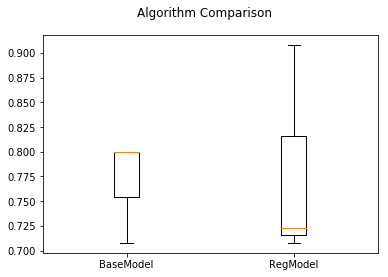

In [29]:
baseModel=DecisionTreeClassifier(criterion='entropy',random_state=5)
regModel=DecisionTreeClassifier(criterion='entropy',max_depth=4,min_samples_leaf=3,random_state=5)

models = []
models.append(("BaseModel",baseModel))
models.append(("RegModel", regModel))
compareModels(models, X,y)

### Observation:
- Regularized model of Max_Depth:4 and min_samples_leaf:3 is giving high variance error compared to fully grown Decision Tree, to the contrary.
- In this comparision Regualized model is giving better accuracy where as in previous test, fully grown Decision Tree was giving better accuracy. 
- Difference between this cross_val_score test and previous step is that, cross_val_score uses 3 fold validation on X and Y where as previous step is using train_test_split. 
- I persume since the data set is small, different splits are giving different results.


# Random Forest Model
## Q8. Next implement the decision tree using Random Forest. What is the optimal number of trees that gives the best result? (10 points)

DT: Mean:0.728205, Varaince:0.013307
DTR2: Mean:0.841026, Varaince:0.012202
RF: Mean:0.789744, Varaince:0.026141


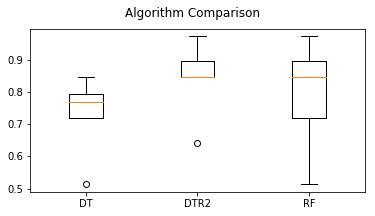

In [98]:
baseModel = DecisionTreeClassifier(criterion='entropy', random_state=5)
optModel = DecisionTreeClassifier(criterion='entropy', max_depth=3, min_samples_leaf=4, random_state=5)
rfModel = RandomForestClassifier(n_estimators=20,criterion='entropy',random_state=5)

models = []
models.append(('DT', baseModel))
models.append(('DTR2', optModel))
models.append(('RF', rfModel))
compareModels(models)

In [31]:
baseModel = RandomForestClassifier(criterion='entropy',random_state=5)
parameter_grid = {'n_estimators': range(1,150,5),
                  'max_depth': range(1,7),
                  'min_samples_leaf': range(1,7)}

GS=GridSearchCV(baseModel,parameter_grid,cv=5)
GS.fit(X_train,y_train)
print("Best Accuracy:",GS.score(X_test,y_test))
print(GS.best_params_)


Best Accuracy: 0.864406779661017
{'max_depth': 6, 'min_samples_leaf': 1, 'n_estimators': 56}


Since we searched for n_estimators with a skip count of 5, lets do another grid search between 50 and 65 to get more fine grain value for n_estimator

In [32]:
baseModel = RandomForestClassifier(criterion='entropy',random_state=5)
parameter_grid = {'n_estimators': range(50,65,5),
                  'max_depth': range(1,7),
                  'min_samples_leaf': range(1,7)}

GS=GridSearchCV(baseModel,parameter_grid,cv=5)
GS.fit(X_train,y_train)
print("Best Accuracy:",GS.score(X_test,y_test))
print(GS.best_params_)


Best Accuracy: 0.864406779661017
{'max_depth': 6, 'min_samples_leaf': 1, 'n_estimators': 55}


BaseModel: Mean:0.769231, Varaince:0.001893
RegModel: Mean:0.779487, Varaince:0.008258
RandomForestModel: Mean:0.784615, Varaince:0.007732


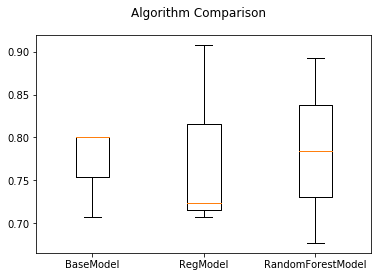

In [33]:
baseModel=DecisionTreeClassifier(criterion='entropy',random_state=5)
regModel=DecisionTreeClassifier(criterion='entropy',max_depth=4,min_samples_leaf=3,random_state=5)
rfModel = RandomForestClassifier(criterion='entropy',n_estimators=55, max_depth=6, min_samples_leaf=1, random_state=5)

models = []
models.append(("BaseModel",baseModel))
models.append(("RegModel", regModel))
models.append(("RandomForestModel", rfModel))
compareModels(models, X,y)

### Observation:
- Optimized Randomforest model is giving better accuracy compared to Decision Tree. And it is giving better varance error compared to Regularized Decision Tree but not as good as "Fully Grown Decision Tree".
- "Fully Grown Decision Tree" seems to be the best model for this data set.
